<a href="https://colab.research.google.com/github/Bunkhuoch-Ann/Side_Quests_simple/blob/main/Grass_proj_notebook1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import matplotlib.pyplot as plt
import numpy as np

img_path = '/content/20260713_111906.jpg'

img = plt.imread(img_path)
img = img[:, :, 0]

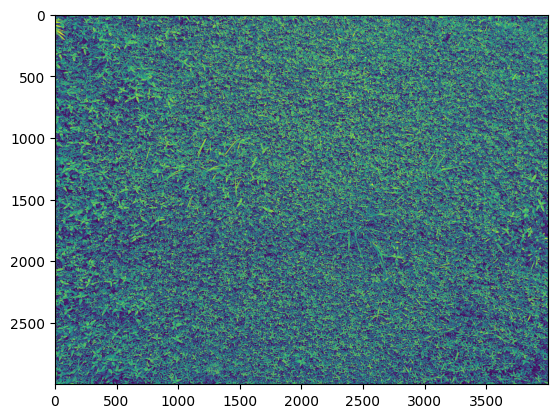

In [3]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.show()

In [4]:
#Simply useless

#Approach 1:
# from scipy.ndimage import laplace
# from scipy.ndimage import gaussian_gradient_magnitude
# edge = np.abs(laplace(img))
# edge = gaussian_gradient_magnitude(img, sigma=0.4)

# #Approach 2:
# from scipy.ndimage import sobel
# import numpy as np
# gx = sobel(img, axis=1)
# gy = sobel(img, axis=0)
# edge = np.sqrt(gx**2 + gy**2)


# img = edge
# plt.imshow(edge)
# plt.show()

(4000,) (3000,)


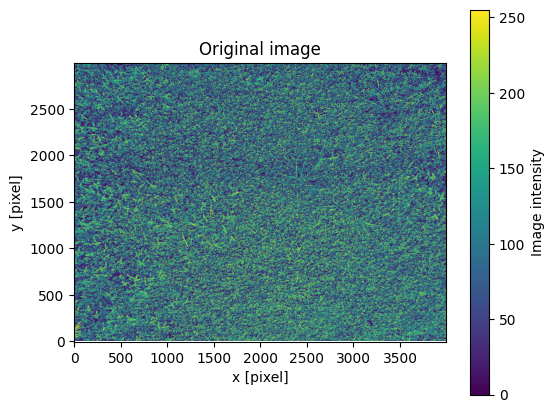

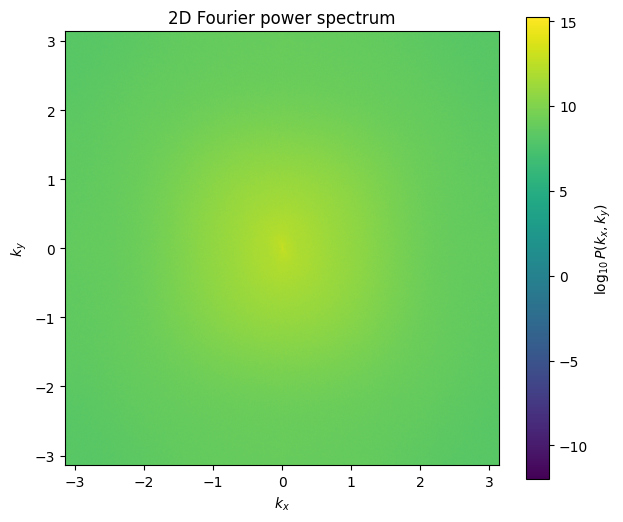

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Image
# --------------------------------------------------

# img should be a 2D NumPy array
# Example:
# img = ...

Ny, Nx = img.shape

# --------------------------------------------------
# Pixel dimensions
# --------------------------------------------------

# Physical size of each pixel
# Change these according to your image

dx = 1.0   # Pixel size in x
dy = 1.0   # Pixel size in y

# Examples:
# dx = dy = 1.0       # Pixel units
# dx = dy = 300.0     # If pixels are 300 km
# dx = dy = 0.5      # If pixels are 0.5 arcsec

# --------------------------------------------------
# Fourier transform
# --------------------------------------------------

# Optional: subtract the mean to remove the DC component
img_centered = img - np.mean(img)

# 2D Fourier transform
F = np.fft.fft2(img_centered)

# Shift zero frequency to the center
F_shifted = np.fft.fftshift(F)

# Power spectrum
P = np.abs(F_shifted)**2

# Logarithmic power for visualization
P_log = np.log10(P + 1e-12)

# --------------------------------------------------
# Wavenumber axes
# --------------------------------------------------

# Fourier frequencies in cycles per physical unit
fx = np.fft.fftshift(np.fft.fftfreq(Nx, d=dx))
fy = np.fft.fftshift(np.fft.fftfreq(Ny, d=dy))
print(np.shape(fx), np.shape(fy))
# Convert to angular wavenumbers:
# k = 2*pi*f

kx = 2 * np.pi * fx
ky = 2 * np.pi * fy

# Create 2D coordinate grids
KX, KY = np.meshgrid(kx, ky)

# --------------------------------------------------
# Plot original image
# --------------------------------------------------

plt.figure(figsize=(6, 5))

plt.imshow(
    img,
    origin="lower",
    aspect="equal"
)

plt.xlabel("x [pixel]")
plt.ylabel("y [pixel]")
plt.colorbar(label="Image intensity")
plt.title("Original image")

plt.show()

# --------------------------------------------------
# Plot 2D power spectrum
# --------------------------------------------------

plt.figure(figsize=(7, 6))

plt.imshow(
    P_log,
    extent=[kx.min(), kx.max(), ky.min(), ky.max()],
    origin="lower",
    aspect="equal"
)

plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.colorbar(label=r"$\log_{10} P(k_x,k_y)$")

plt.title("2D Fourier power spectrum")

plt.show()

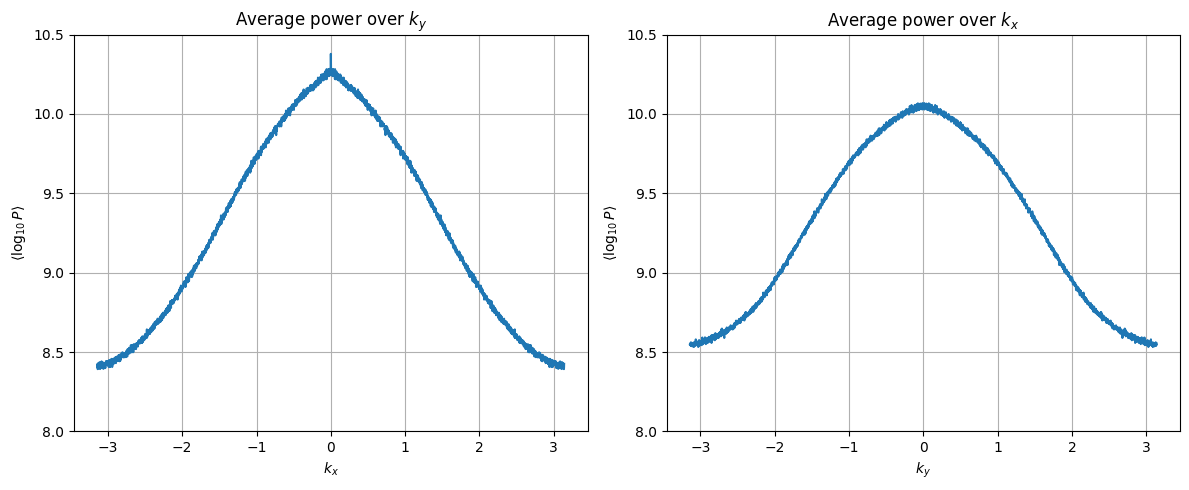

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Average over ky → P as a function of kx
P_vs_kx = np.mean(P_log, axis=0)

# Average over kx → P as a function of ky
P_vs_ky = np.mean(P_log, axis=1)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# P vs kx
axes[0].plot(kx, P_vs_kx)
axes[0].set_xlabel(r"$k_x$")
axes[0].set_ylabel(r"$\langle \log_{10} P \rangle$")
axes[0].set_title(r"Average power over $k_y$")
axes[0].grid(True)
axes[0].set_ylim(8, 10.5)

# P vs ky
axes[1].plot(ky, P_vs_ky)
axes[1].set_xlabel(r"$k_y$")
axes[1].set_ylabel(r"$\langle \log_{10} P \rangle$")
axes[1].set_title(r"Average power over $k_x$")
axes[1].grid(True)
axes[1].set_ylim(8, 10.5)

plt.tight_layout()
plt.show()

In [7]:
# --------------------------------------------------
# Radially averaged power spectrum
# using logarithmic k bins
# --------------------------------------------------

K = np.sqrt(KX**2 + KY**2)

K_flat = K.ravel()
P_flat = P.ravel()

# Remove k = 0
valid = K_flat > 0

K_flat = K_flat[valid]
P_flat = P_flat[valid]

# Logarithmic bins
k_min = K_flat.min()
k_max = K_flat.max()

k_bins = np.logspace(
    np.log10(k_min),
    np.log10(k_max),
    100
)

bin_indices = np.digitize(K_flat, k_bins)

k_values = []
P_values = []

for i in range(1, len(k_bins)):

    mask = bin_indices == i

    if np.any(mask):

        # Geometric mean is better for logarithmic k
        k_values.append(
            np.exp(np.mean(np.log(K_flat[mask])))
        )

        # Mean power
        P_values.append(
            np.mean(P_flat[mask])
        )

k_values = np.array(k_values)
P_values = np.array(P_values)

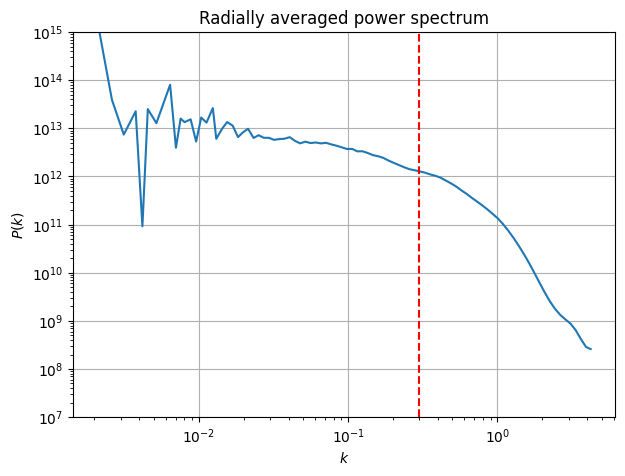

In [8]:
# Plot radial power spectrum
plt.figure(figsize=(7, 5))

plt.loglog(k_values, P_values)
plt.axvline(x=0.3, color='r', linestyle='--')

plt.ylim(1e7, 1e15)
plt.xlabel(r"$k$")
plt.ylabel(r"$P(k)$")
plt.title("Radially averaged power spectrum")

plt.grid(True)
plt.show()

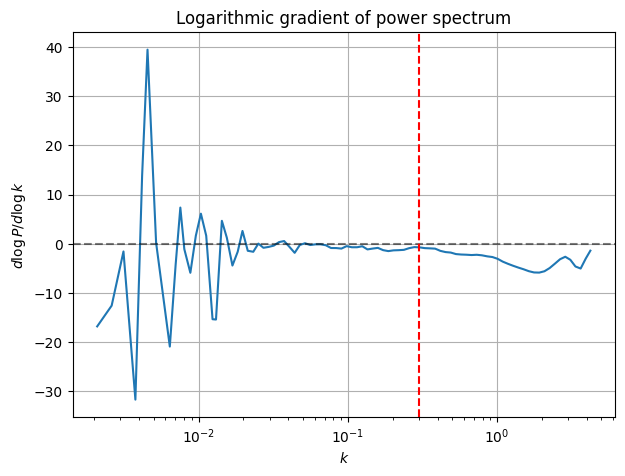

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Convert to log space
log_k = np.log10(k_values)
log_P = np.log10(P_values)

# Gradient d(log P) / d(log k)
gradient = np.gradient(log_P, log_k)
# gradient = np.gradient(P_values, k_values)

# --------------------------------------------------
# Plot gradient
# --------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(k_values, gradient)

plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.axvline(x=0.3, color='r', linestyle='--')

plt.xscale('log')
# plt.ylim(-100, 100)
plt.xlabel(r"$k$")
plt.ylabel(r"$d\log P / d\log k$")
plt.title("Logarithmic gradient of power spectrum")

plt.grid(True)
plt.show()

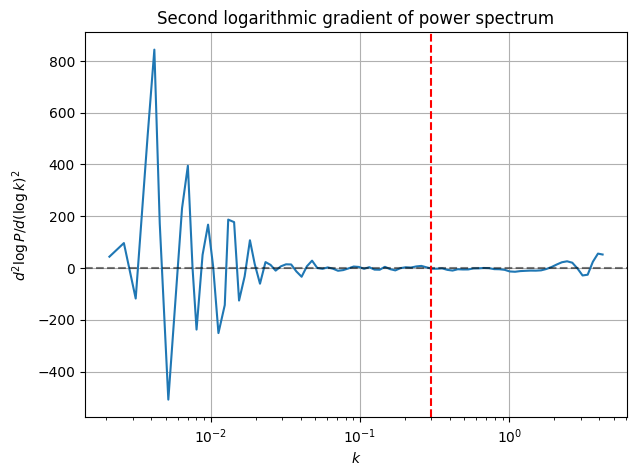

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Logarithmic coordinates
# --------------------------------------------------

log_k = np.log10(k_values)
log_P = np.log10(P_values)

# --------------------------------------------------
# First gradient
# --------------------------------------------------

dlogP_dlogk = np.gradient(log_P, log_k)

# --------------------------------------------------
# Second gradient
# --------------------------------------------------

d2logP_dlogk2 = np.gradient(
    dlogP_dlogk,
    log_k
)

# --------------------------------------------------
# Plot second gradient
# --------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(
    k_values,
    d2logP_dlogk2
)

# Zero line = possible inflection points
plt.axhline(
    0,
    color='k',
    linestyle='--',
    alpha=0.5
)

# Your existing reference
plt.axvline(
    x=0.3,
    color='r',
    linestyle='--'
)

plt.xscale('log')

plt.xlabel(r"$k$")
plt.ylabel(r"$d^2\log P / d(\log k)^2$")

plt.title("Second logarithmic gradient of power spectrum")

plt.grid(True)

plt.show()

In [11]:
# --------------------------------------------------
# Find zero crossings
# --------------------------------------------------

sign_change = np.diff(
    np.sign(d2logP_dlogk2)
)

inflection_indices = np.where(
    sign_change != 0
)[0]

print("Possible inflection points:")

for i in inflection_indices:

    k_inflection = k_values[i]

    scale = 2 * np.pi / k_inflection

    print(
        f"k = {k_inflection:.5g}, "
        f"scale = {scale:.3g} [physical units]"
    )

Possible inflection points:
k = 0.002618, scale = 2.4e+03 [physical units]
k = 0.0031416, scale = 2e+03 [physical units]
k = 0.0045518, scale = 1.38e+03 [physical units]
k = 0.0051963, scale = 1.21e+03 [physical units]
k = 0.0070248, scale = 894 [physical units]
k = 0.0080303, scale = 782 [physical units]
k = 0.010369, scale = 606 [physical units]
k = 0.012409, scale = 506 [physical units]
k = 0.01433, scale = 438 [physical units]
k = 0.016864, scale = 373 [physical units]
k = 0.019694, scale = 319 [physical units]
k = 0.021366, scale = 294 [physical units]
k = 0.025155, scale = 250 [physical units]
k = 0.027201, scale = 231 [physical units]
k = 0.034564, scale = 182 [physical units]
k = 0.040595, scale = 155 [physical units]
k = 0.047694, scale = 132 [physical units]
k = 0.056003, scale = 112 [physical units]
k = 0.060712, scale = 103 [physical units]
k = 0.083641, scale = 75.1 [physical units]
k = 0.098136, scale = 64 [physical units]
k = 0.1064, scale = 59.1 [physical units]
k = 0.1

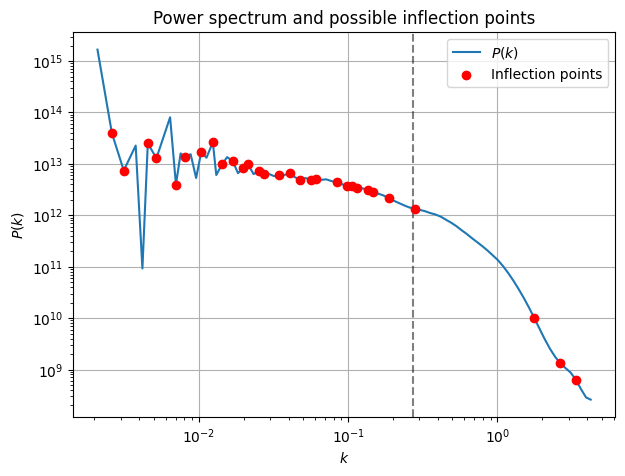

In [12]:
plt.figure(figsize=(7, 5))

plt.loglog(
    k_values,
    P_values,
    label=r"$P(k)$"
)

# Mark possible inflection points
plt.scatter(
    k_values[inflection_indices],
    P_values[inflection_indices],
    color='red',
    zorder=5,
    label="Inflection points"
)

plt.axvline(
    x=0.27,
    color='k',
    linestyle='--',
    alpha=0.5
)

plt.xlabel(r"$k$")
plt.ylabel(r"$P(k)$")

plt.title("Power spectrum and possible inflection points")

plt.grid(True)
plt.legend()

plt.show()

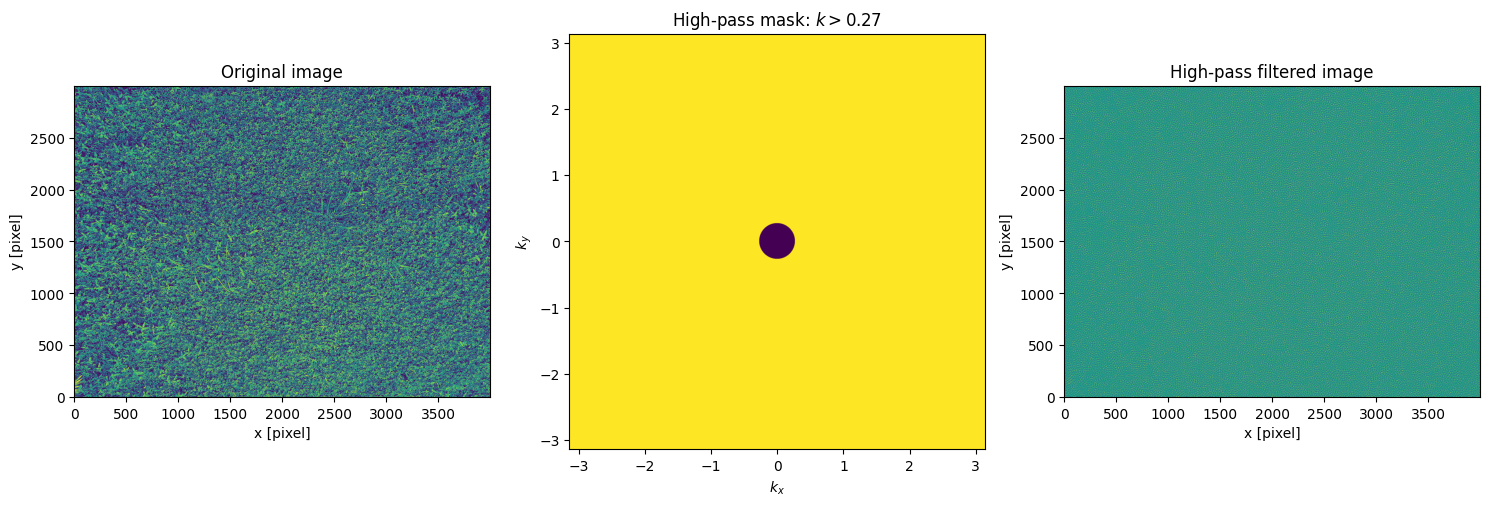

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Image
# --------------------------------------------------

Ny, Nx = img.shape

# Pixel dimensions
dx = 1.0
dy = 1.0

# --------------------------------------------------
# Fourier transform
# --------------------------------------------------

# Remove the mean first
img_centered = img - np.mean(img)

F = np.fft.fft2(img_centered)

# Shift zero frequency to the center
F_shifted = np.fft.fftshift(F)

# --------------------------------------------------
# Construct kx, ky
# --------------------------------------------------

fx = np.fft.fftshift(np.fft.fftfreq(Nx, d=dx))
fy = np.fft.fftshift(np.fft.fftfreq(Ny, d=dy))

kx = 2 * np.pi * fx
ky = 2 * np.pi * fy

KX, KY = np.meshgrid(kx, ky)

# Magnitude of wavenumber
K = np.sqrt(KX**2 + KY**2)

# --------------------------------------------------
# High-pass filter
# --------------------------------------------------

k_cut = 0.27   # <-- choose your threshold

# Keep only k > k_cut
mask = K > k_cut

# Apply filter
F_filtered = F_shifted * mask

# --------------------------------------------------
# Inverse Fourier transform
# --------------------------------------------------

# Shift back before inverse FFT
F_filtered = np.fft.ifftshift(F_filtered)

img_filtered = np.fft.ifft2(F_filtered)

# The result should be real, but numerical errors
# can leave a tiny imaginary component
img_filtered = np.real(img_filtered)

# --------------------------------------------------
# Plot
# --------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original
axes[0].imshow(
    img,
    origin="lower",
    aspect="equal"
)
axes[0].set_title("Original image")
axes[0].set_xlabel("x [pixel]")
axes[0].set_ylabel("y [pixel]")

# Fourier mask
axes[1].imshow(
    mask,
    extent=[kx.min(), kx.max(), ky.min(), ky.max()],
    origin="lower",
    aspect="equal"
)
axes[1].set_title(rf"High-pass mask: $k > {k_cut}$")
axes[1].set_xlabel(r"$k_x$")
axes[1].set_ylabel(r"$k_y$")

# Filtered image
axes[2].imshow(
    img_filtered,
    origin="lower",
    aspect="equal"
)
axes[2].set_title("High-pass filtered image")
axes[2].set_xlabel("x [pixel]")
axes[2].set_ylabel("y [pixel]")

plt.tight_layout()
plt.show()

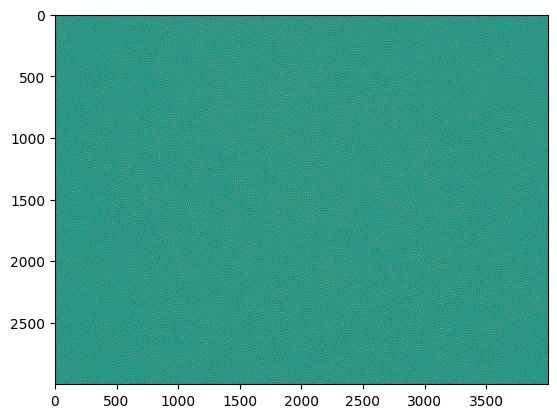

In [14]:
plt.imshow(img_filtered)
plt.savefig("img_filtered.png")

In [15]:
import numpy as np

# Pixel size
dx = 1   # physical size of one pixel, e.g. km

# Choose your Fourier cutoff
# k_cut = 0.005   # inverse physical length, e.g. km^-1

# Corresponding wavelength / physical length scale
lambda_cut = 2 * np.pi / k_cut

# Corresponding number of pixels
N_pixels = lambda_cut / dx

print(f"k_cut = {k_cut:.5f} [1/px]")
print(f"Characteristic length = {lambda_cut:.2f} pixels")
print(f"Characteristic size = {N_pixels:.2f} pixels")

k_cut = 0.27000 [1/px]
Characteristic length = 23.27 pixels
Characteristic size = 23.27 pixels
